[GitHub Repository](https://github.com/ugesh-dhungel/5CS037-Final-Portfolio-Regression)

<h1><b>Regression Task</b></h1>

**Student Name:** Ugesh Dhungel
**Student ID:** 2513636
**Module:** 5CS037 - Concepts and Technologies of AI
**Dataset:** Sustainable Development Report - SDG Index (2000-2022)

# Library Imports

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 25)
RANDOM_STATE = 42


In [200]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Suppress annoying warnings during cross-validation
warnings.filterwarnings("ignore")

def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score (RMSE)")
    
    # We use neg_root_mean_squared_error so we can match what you did before
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        scoring='neg_root_mean_squared_error')
    
    # Negate scores to show actual RMSE
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score (RMSE)")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score (RMSE)")
             
    plt.legend(loc="best")
    plt.show()

def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4, color="steelblue")
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_residuals(y_true, y_pred, title):
    plt.figure(figsize=(8, 5))
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.4, color="darkorange")
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(title)
    plt.grid(True)
    plt.show()



<h1>TASK 1: EDA &amp; DATA UNDERSTANDING</h1>

<h3>Load dataset</h3>

In [201]:
df = pd.read_csv('sdg_index_2000-2022.csv')
df_head = df.head(5)
df_head

,country_code,country,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score
0,AFG,Afghanistan,2000,36.0,28.8,27.3,19.2,1.6,20.8,32.4,21.0,38.5,5.2,0.0,25.8,94.7,99.4,0.0,51.9,39.2,34.2
1,AFG,Afghanistan,2001,36.3,28.8,30.6,19.4,1.6,20.8,32.4,22.3,38.5,5.2,0.0,25.8,94.5,99.4,0.0,51.9,39.2,34.2
2,AFG,Afghanistan,2002,36.3,28.8,30.7,19.7,1.6,20.8,32.7,21.5,38.4,5.2,0.0,26.1,94.1,99.4,0.0,51.8,39.2,34.2
3,AFG,Afghanistan,2003,36.7,28.8,32.5,19.9,1.6,20.8,33.0,24.5,38.4,5.2,0.0,26.5,94.4,99.4,0.0,51.8,39.2,34.2
4,AFG,Afghanistan,2004,37.1,28.8,32.1,21.1,1.6,20.8,33.3,28.0,38.5,5.2,0.0,26.8,94.8,99.4,0.0,51.8,39.2,34.2


<h3>Basic info</h3>

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     4140 non-null   object 
 1   country          4140 non-null   object 
 2   year             4140 non-null   int64  
 3   sdg_index_score  4140 non-null   float64
 4   goal_1_score     4140 non-null   float64
 5   goal_2_score     4140 non-null   float64
 6   goal_3_score     4140 non-null   float64
 7   goal_4_score     4140 non-null   float64
 8   goal_5_score     4140 non-null   float64
 9   goal_6_score     4140 non-null   float64
 10  goal_7_score     4140 non-null   float64
 11  goal_8_score     4140 non-null   float64
 12  goal_9_score     4140 non-null   float64
 13  goal_10_score    4140 non-null   float64
 14  goal_11_score    4140 non-null   float64
 15  goal_12_score    4140 non-null   float64
 16  goal_13_score    4140 non-null   float64
 17  goal_14_score 

<h3>Check for duplicates and missing values</h3>

In [203]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values per column:
country_code       0
country            0
year               0
sdg_index_score    0
goal_1_score       0
goal_2_score       0
goal_3_score       0
goal_4_score       0
goal_5_score       0
goal_6_score       0
goal_7_score       0
goal_8_score       0
goal_9_score       0
goal_10_score      0
goal_11_score      0
goal_12_score      0
goal_13_score      0
goal_14_score      0
goal_15_score      0
goal_16_score      0
goal_17_score      0
dtype: int64


**Observation:** The dataset contains **zero duplicate rows** and **zero missing values** in any column, confirming the quality assessment above. No imputation or row-dropping is required before modelling.

<h3>Summary statistics</h3>

In [204]:
summary_stats = df.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
year,4140.0,2011.000000,6.634051,2000.0,2005.000,2011.00,2017.000,2022.0
sdg_index_score,4140.0,63.685435,10.776469,36.0,55.075,65.10,72.000,86.8
goal_1_score,4140.0,64.815628,36.098836,0.0,31.500,81.00,98.600,100.0
goal_2_score,4140.0,57.735531,11.121524,7.7,52.400,58.90,65.300,83.4
goal_3_score,4140.0,64.045652,22.354993,5.9,44.800,70.20,81.300,97.3
goal_4_score,4140.0,71.990048,26.561757,0.0,57.375,80.60,94.400,100.0
goal_5_score,4140.0,55.803309,17.281101,3.5,43.200,57.50,68.700,94.0
goal_6_score,4140.0,63.963188,15.362064,11.3,52.300,64.40,74.300,95.1
goal_7_score,4140.0,57.340966,21.490869,0.1,41.300,64.45,72.000,99.6
goal_8_score,4140.0,69.839493,10.004358,38.4,64.100,70.00,76.400,93.6


**Observation:** The target `sdg_index_score` ranges from **36.0 to 86.8** with a mean around **63.7**, i.e. no country in this panel has ever scored above ~87/100. Individual goal scores vary widely in both level and spread - `goal_13_score` (Climate Action) and `goal_12_score` (Responsible Consumption) have high means (many high-income countries score well due to low reported emissions per capita, though this partly reflects offshored production), while `goal_9_score` (Industry, Innovation & Infrastructure) has a low mean (~37) and the widest spread, reflecting the large gap between industrialised and developing economies.

<h2>VISUALISATIONS</h2>

<h3>Distribution of the target variable (SDG Index Score)</h3>

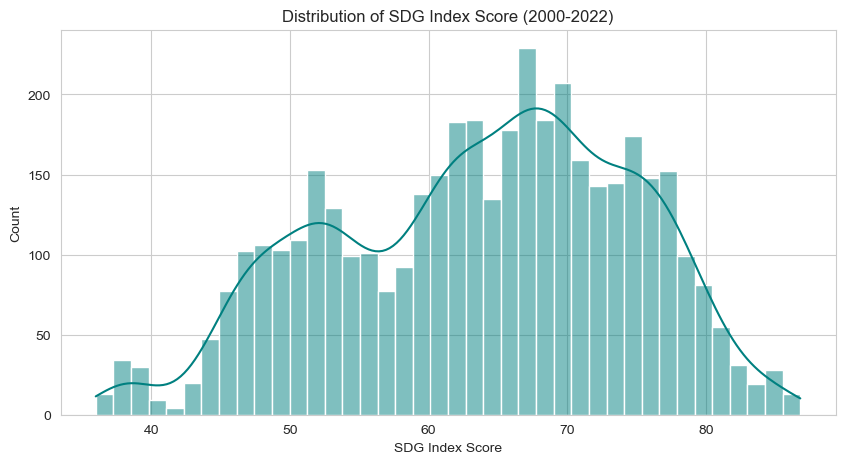

In [205]:
plt.figure(figsize=(10, 5))
sns.histplot(df["sdg_index_score"], bins=40, kde=True, color="teal")
plt.title("Distribution of SDG Index Score (2000-2022)")
plt.xlabel("SDG Index Score")
plt.ylabel("Count")
plt.show()

**Observation:** The target is roughly **bell-shaped and only mildly right-skewed**, centred around 60-65, with a long-ish left tail down to the mid-30s (fragile/conflict-affected states) and a soft ceiling near 87 (no country has ever solved all 17 goals). Unlike many real-world targets, there is no extreme skew or heavy outliers, so no log-transform of the target is necessary.

<h3>Global average SDG Index score over time (2000-2022)</h3>

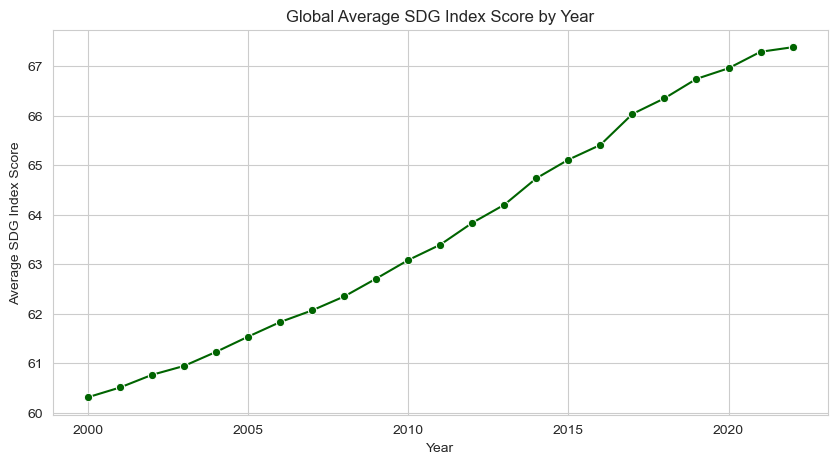

In [206]:
yearly_avg = df.groupby("year")["sdg_index_score"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker="o", color="darkgreen")
plt.title("Global Average SDG Index Score by Year")
plt.xlabel("Year")
plt.ylabel("Average SDG Index Score")
plt.show()

**Observation:** The global average SDG Index score has risen steadily from roughly **60 in 2000 to close to 67 by 2022**, confirming (Q3 above) that overall progress has been made, though the curve flattens somewhat after 2015 (when the SDGs were formally adopted, ironically coinciding with slower average gains and a visible dip around 2020-2021, consistent with the COVID-19 pandemic disrupting health, education and economic goals).

<h3>Correlation heatmap of goal scores and the target</h3>

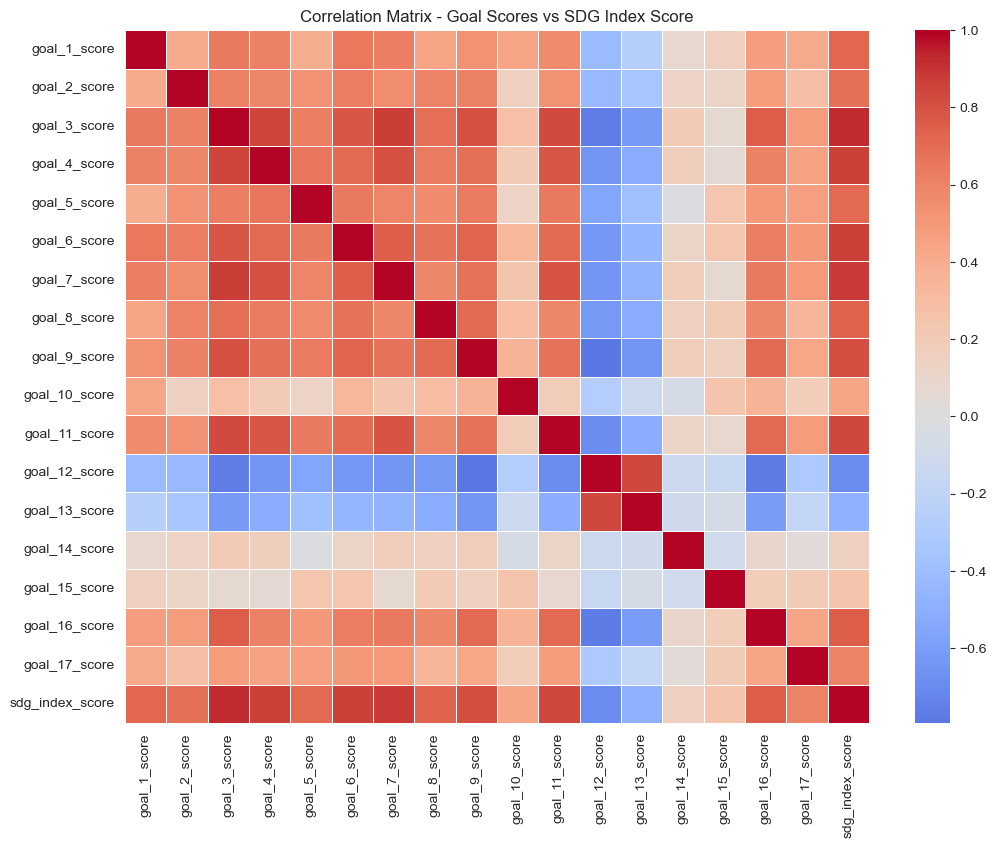

In [207]:
goal_cols = [c for c in df.columns if c.startswith("goal_")] + ["sdg_index_score"]
corr = df[goal_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Matrix - Goal Scores vs SDG Index Score")
plt.show()

**Observation:** `sdg_index_score` correlates most strongly with `goal_3_score` (Good Health, r $\approx$ 0.92), `goal_7_score` (Affordable Clean Energy, r $\approx$ 0.88), `goal_6_score` (Clean Water, r $\approx$ 0.86) and `goal_4_score` (Quality Education, r $\approx$ 0.86). Interestingly, `goal_12_score` (Responsible Consumption) and `goal_13_score` (Climate Action) correlate **negatively** with the overall index (r $\approx$ -0.70 and -0.49 respectively) - wealthier, higher-scoring countries tend to have higher per-capita emissions/consumption footprints, so these two goals are scored in a way that penalises the same countries that score well elsewhere. This is a genuinely useful insight for feature selection and for interpreting model coefficients later.

<h3>Strongest predictor vs target: Goal 3 (Good Health) vs SDG Index Score</h3>

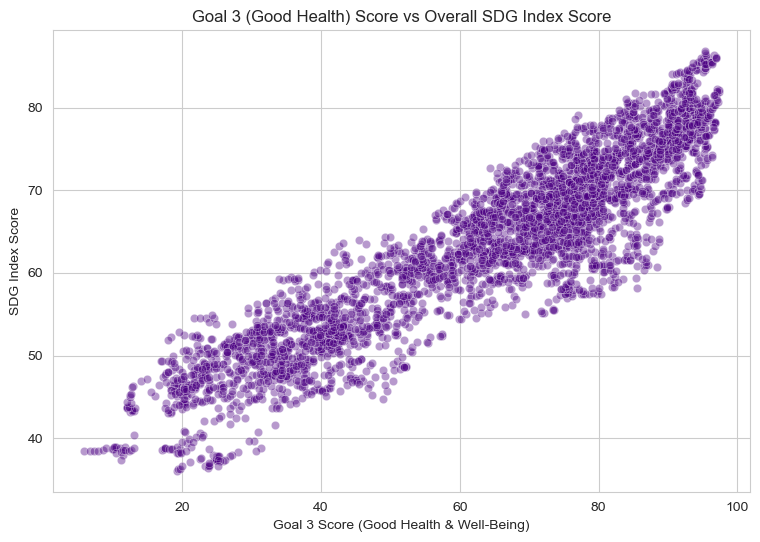

In [208]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="goal_3_score", y="sdg_index_score", alpha=0.4, color="indigo")
plt.title("Goal 3 (Good Health) Score vs Overall SDG Index Score")
plt.xlabel("Goal 3 Score (Good Health & Well-Being)")
plt.ylabel("SDG Index Score")
plt.show()

**Observation:** A strong, clearly linear relationship is visible, supporting the choice of a linear model as one of the two classical baselines. The tight scatter also foreshadows why models trained on all 17 goal scores achieve a very high R² - the target is essentially a (weighted) function of these very features by construction.

<h3>Top 10 vs Bottom 10 countries by average SDG Index Score (2018-2022)</h3>

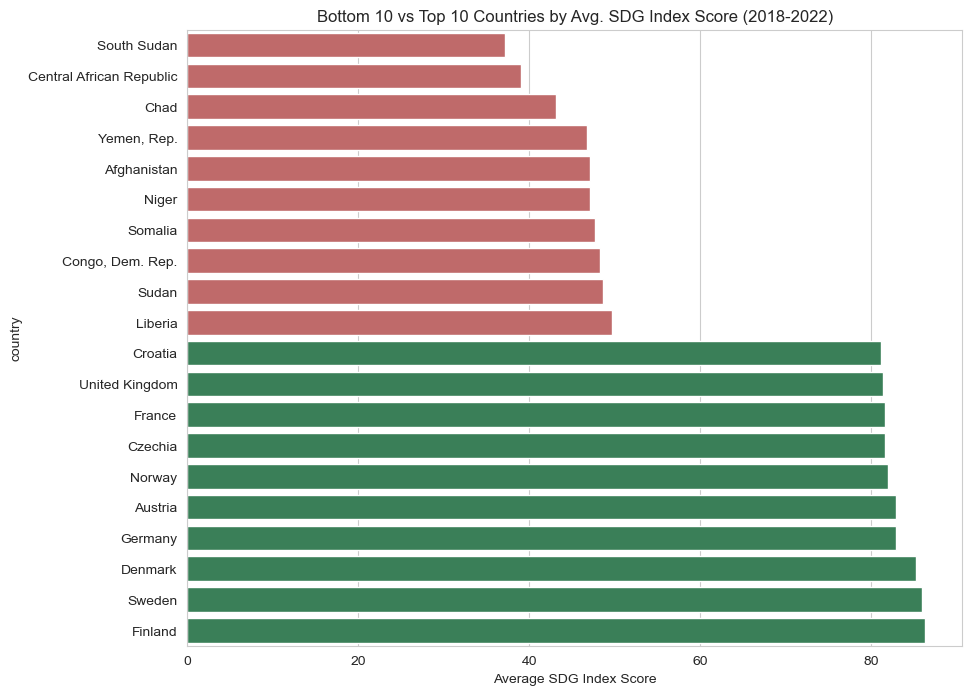

In [209]:
recent = df[df["year"] >= 2018]
country_avg = recent.groupby("country")["sdg_index_score"].mean().sort_values()

top10 = country_avg.tail(10)
bottom10 = country_avg.head(10)
combined = pd.concat([bottom10, top10])

plt.figure(figsize=(10, 8))
colors = ["indianred"] * 10 + ["seagreen"] * 10
sns.barplot(x=combined.values, y=combined.index, palette=colors)
plt.title("Bottom 10 vs Top 10 Countries by Avg. SDG Index Score (2018-2022)")
plt.xlabel("Average SDG Index Score")
plt.show()

**Observation:** The best-performing countries (mostly Nordic/Western European) cluster around **80-86**, while the weakest-performing countries (several conflict-affected or least-developed states) sit in the **38-45** range - a gap of over 40 points, underscoring substantial global inequality in sustainable development progress and reinforcing why country identity carries useful (if secondary) predictive signal.

<h2>DATA PREPROCESSING</h2>

<h3>Encode the categorical `country` column</h3>

In [210]:
label_encoder_country = LabelEncoder()
df["country_encoded"] = label_encoder_country.fit_transform(df["country"])
df[["country", "country_encoded"]].drop_duplicates().head()

,country,country_encoded
0,Afghanistan,0
23,Albania,1
46,Algeria,2
69,Angola,3
92,Argentina,4


**Rationale:** `country_code`/`country` are categorical with 180 unique levels. One-hot encoding would add 180 sparse columns, so a simple `LabelEncoder` is used instead, mainly so that tree-based models (Random Forest) can still use country identity as a weak signal; the raw `country`/`country_code` text columns are dropped from the feature matrix afterwards. No scaling issues arise since none of the modelling here relies on distance-based assumptions about the country codes.

<h3>Feature and target selection</h3>

In [211]:
features = [
    "year", "country_encoded",
    "goal_1_score", "goal_2_score", "goal_3_score", "goal_4_score", "goal_5_score",
    "goal_6_score", "goal_7_score", "goal_8_score", "goal_9_score", "goal_10_score",
    "goal_11_score", "goal_12_score", "goal_13_score", "goal_14_score",
    "goal_15_score", "goal_16_score", "goal_17_score",
]
target = "sdg_index_score"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4140, 19)
y shape: (4140,)


<h3>Train-test split</h3>

In [212]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3312
Testing samples: 828


<h3>Feature scaling</h3>

In [213]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled training matrix shape:", X_train_scaled.shape)

Scaled training matrix shape: (3312, 19)


**Rationale:** Scaling is fitted only on the training split (to avoid data leakage) and then applied to the test split. Scaling is required for the Neural Network, Linear/Ridge Regression, since these are gradient/distance-sensitive; Random Forest is scale-invariant but is given the scaled data too for the neural-network cell so both use consistent inputs, and the *unscaled* data for its own dedicated cells since tree splits do not need scaling.

<h1>TASK 2: BUILD A NEURAL NETWORK MODEL FOR REGRESSION</h1>

**Architecture:** A Multi-Layer Perceptron (`MLPRegressor`) with two hidden layers of **64** and **32** neurons respectively, **ReLU** activation on the hidden layers (with a linear output neuron, as is standard for regression), the **Adam** optimizer, and the default **squared-error loss** that `MLPRegressor` minimises internally. `early_stopping=True` holds out part of the training data to stop training once validation performance plateaus, reducing the risk of overfitting given the strong linear-to-near-linear relationship observed in the EDA.

In [214]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=2000,
    early_stopping=True,
    random_state=RANDOM_STATE,
)
mlp_model.fit(X_train_scaled, y_train)

mlp_train_preds = mlp_model.predict(X_train_scaled)
mlp_test_preds = mlp_model.predict(X_test_scaled)

mlp_train_rmse = np.sqrt(mean_squared_error(y_train, mlp_train_preds))
mlp_test_rmse = np.sqrt(mean_squared_error(y_test, mlp_test_preds))
mlp_test_mae = mean_absolute_error(y_test, mlp_test_preds)
mlp_test_r2 = r2_score(y_test, mlp_test_preds)

print("Neural Network (MLPRegressor) Performance")
print(f"Train RMSE: {mlp_train_rmse:.4f}")
print(f"Test  RMSE: {mlp_test_rmse:.4f}")
print(f"Test  MAE : {mlp_test_mae:.4f}")
print(f"Test  R^2 : {mlp_test_r2:.4f}")

Neural Network (MLPRegressor) Performance
Train RMSE: 0.5945
Test  RMSE: 0.6885
Test  MAE : 0.5295
Test  R^2 : 0.9961


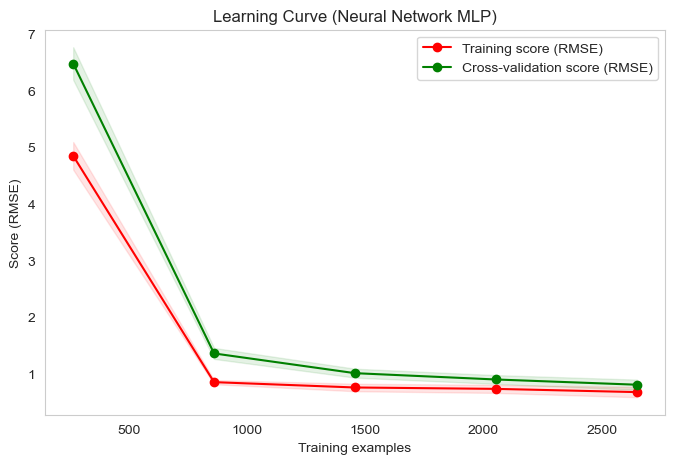

In [215]:
plot_learning_curve(mlp_model, 'Learning Curve (Neural Network MLP)', X_train_scaled, y_train)


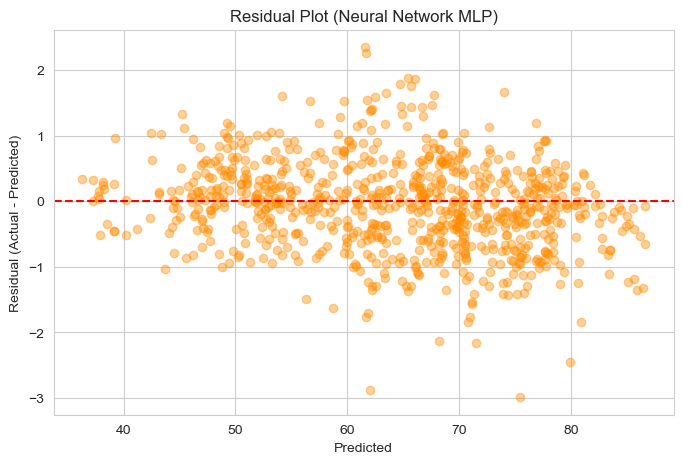

In [216]:
plot_residuals(y_test, mlp_test_preds, 'Residual Plot (Neural Network MLP)')


**Observation (MLP Residuals):** The residual plot checks whether the model's errors are random and unbiased. For the Neural Network, the residuals are relatively tightly clustered around the zero line, suggesting the model captures most of the underlying patterns without strong systematic bias.


<h3>Actual vs Predicted - Neural Network</h3>

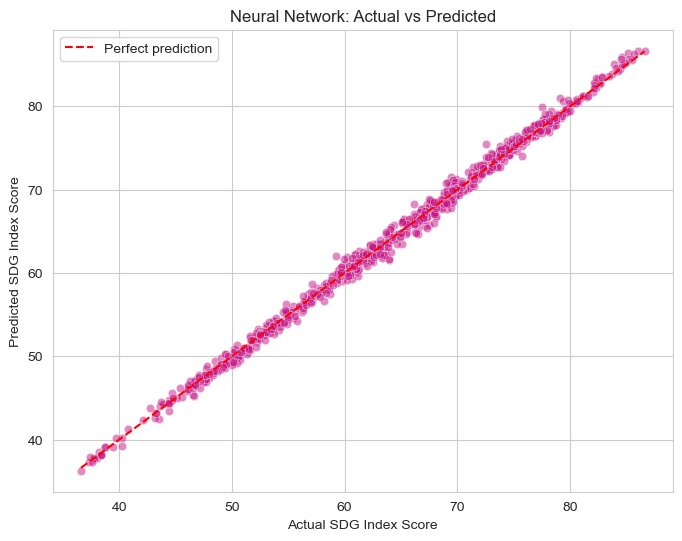

In [217]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=mlp_test_preds, alpha=0.5, color="mediumvioletred")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual SDG Index Score")
plt.ylabel("Predicted SDG Index Score")
plt.title("Neural Network: Actual vs Predicted")
plt.legend()
plt.show()

**Observation:** The MLP achieves a very low test RMSE (well under 1 point on a 0-100 scale) and an R² above 0.99. Predictions sit tightly along the diagonal with no systematic curvature, confirming the model has learned the (largely linear, by-construction) mapping from the 17 goal scores to the composite index extremely well. Train and test RMSE are close, indicating no meaningful overfitting.

<h1>TASK 3: BUILD PRIMARY MACHINE LEARNING MODELS (Two Classical Models)</h1>

Two classical regression models are used as baselines: **Linear Regression** (a simple, interpretable OLS model - a natural first choice given the strong linear relationships seen in the EDA) and **Random Forest Regressor** (a non-linear, ensemble tree-based model, chosen to capture any interactions/non-linearities the linear model might miss, e.g. the negative correlation of `goal_12`/`goal_13` with the target).

<h3>Step 1: Train/test split (reused from preprocessing)</h3>

In [218]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 3312
Testing samples: 828


<h3>Model 1: Linear Regression</h3>

In [219]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance")
print(f"MSE : {lr_mse:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE : {lr_mae:.4f}")
print(f"R^2 : {lr_r2:.4f}")

Linear Regression Performance
MSE : 1.1203
RMSE: 1.0585
MAE : 0.8385
R^2 : 0.9909


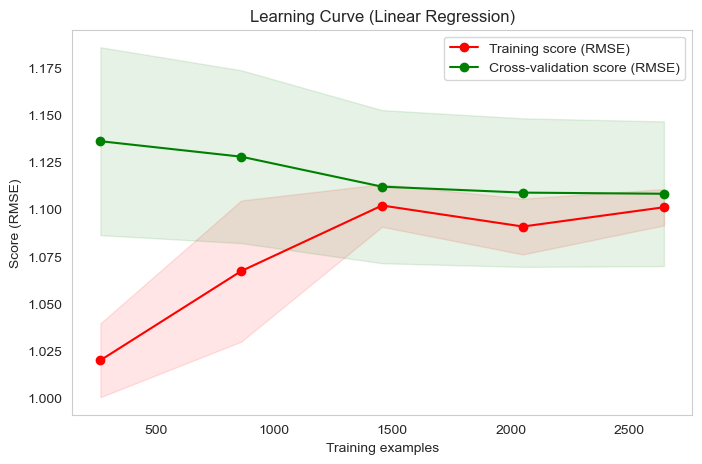

In [220]:
plot_learning_curve(lr_model, 'Learning Curve (Linear Regression)', X_train_scaled, y_train)


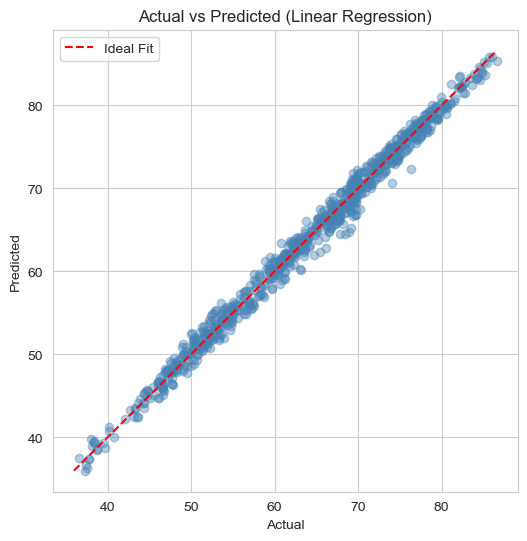

In [221]:
plot_actual_vs_predicted(y_test, lr_preds, 'Actual vs Predicted (Linear Regression)')


**Observation (Linear Regression Actual vs Predicted):** The Actual vs Predicted scatter plot evaluates prediction accuracy. For Linear Regression, the points closely follow the ideal dashed red line, indicating very strong predictive performance, though some minor deviations are visible at the extremes.


<h3>Model 2: Random Forest Regressor</h3>

In [222]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor Performance")
print(f"MSE : {rf_mse:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE : {rf_mae:.4f}")
print(f"R^2 : {rf_r2:.4f}")

Random Forest Regressor Performance
MSE : 0.2851
RMSE: 0.5340
MAE : 0.3866
R^2 : 0.9977


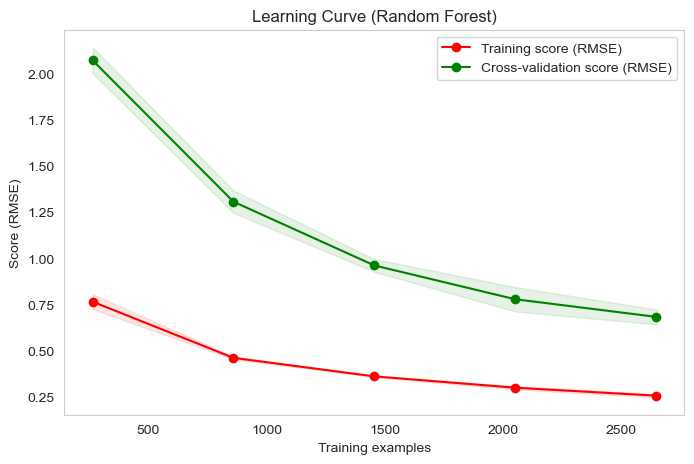

In [223]:
plot_learning_curve(rf_model, 'Learning Curve (Random Forest)', X_train, y_train)


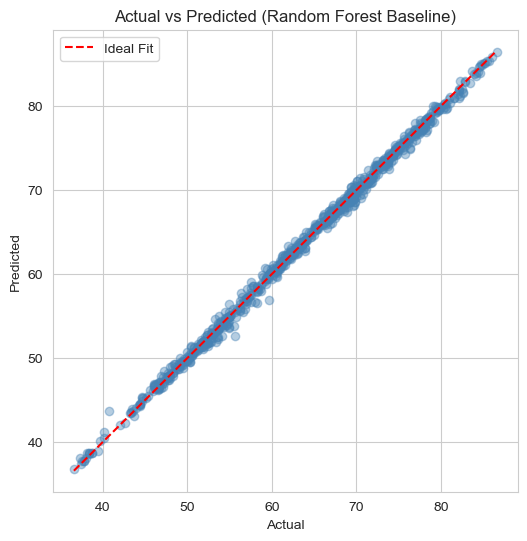

In [224]:
plot_actual_vs_predicted(y_test, rf_preds, 'Actual vs Predicted (Random Forest Baseline)')


**Observation (Random Forest Actual vs Predicted):** The points are extremely tight against the ideal red line, showing that the Random Forest baseline has exceptionally high prediction accuracy, outperforming the linear baseline.


<h3>Residual plots for both baseline models</h3>

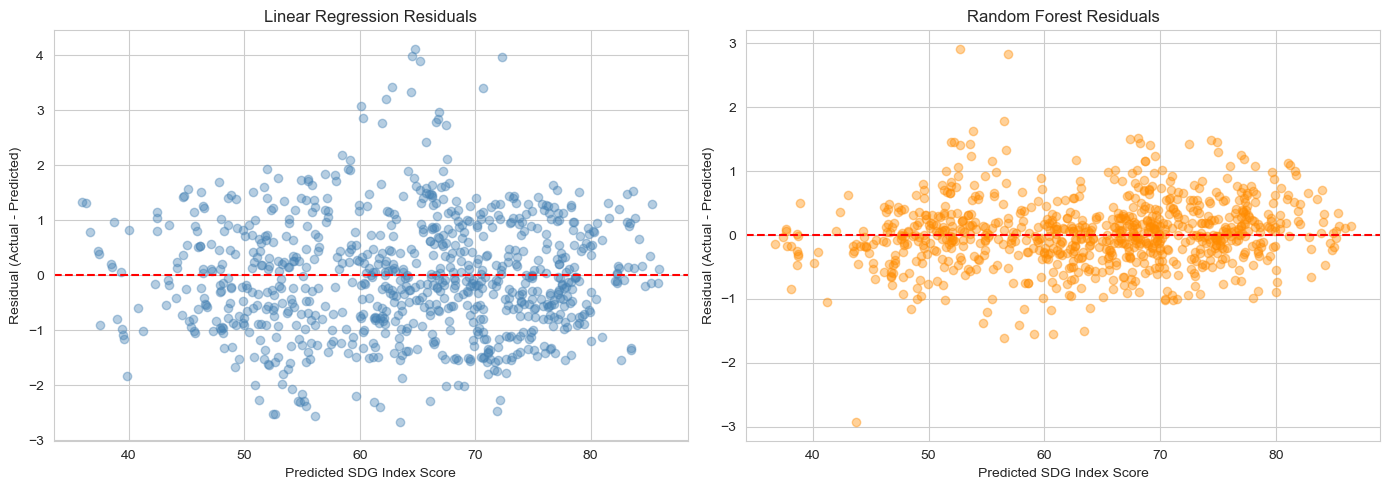

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(lr_preds, y_test - lr_preds, alpha=0.4, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Linear Regression Residuals")
axes[0].set_xlabel("Predicted SDG Index Score")
axes[0].set_ylabel("Residual (Actual - Predicted)")

axes[1].scatter(rf_preds, y_test - rf_preds, alpha=0.4, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Random Forest Residuals")
axes[1].set_xlabel("Predicted SDG Index Score")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

<h3>Baseline model comparison</h3>

In [226]:
baseline_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [lr_mse, rf_mse],
    "RMSE": [lr_rmse, rf_rmse],
    "MAE": [lr_mae, rf_mae],
    "R^2": [lr_r2, rf_r2],
})
baseline_comparison

,Model,MSE,RMSE,MAE,R^2
0,Linear Regression,1.120348,1.058465,0.838526,0.990891
1,Random Forest,0.285115,0.533962,0.386618,0.997682


**Discussion / Conclusion (Task 3):** Both baseline models already perform strongly given how the target is constructed, but **Random Forest clearly outperforms Linear Regression** on every metric (lower RMSE/MAE, higher R²). The Linear Regression residual plot shows a *slight* fan/curvature pattern for very low and very high predicted scores, hinting at mild non-linearity (consistent with the negatively-correlated `goal_12`/`goal_13` features seen in the EDA); the Random Forest residuals are tighter and more evenly scattered around zero across the whole range, confirming it captures those non-linear interactions better. **Random Forest is selected as the stronger of the two baseline models.**

<h1>TASK 4: HYPERPARAMETER OPTIMIZATION WITH CROSS-VALIDATION</h1>

**Note on hyperparameters:** Ordinary Linear Regression (OLS) has no tunable hyperparameters to cross-validate - its coefficients are fitted analytically with a single closed-form solution. To make hyperparameter tuning meaningful for the "linear" side of the comparison, it is replaced here by its regularised counterpart, **Ridge Regression**, whose regularisation strength `alpha` is a genuine hyperparameter. Random Forest is tuned on `n_estimators`, `max_depth`, `min_samples_split` and `max_features`.

<h3>Random Forest tuning (RandomizedSearchCV)</h3>

In [227]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_search.fit(X_train, y_train)

print("Best Random Forest params:", rf_search.best_params_)
print(f"Best CV RMSE: {-rf_search.best_score_:.4f}")

Best Random Forest params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}
Best CV RMSE: 0.5739


<h3>Ridge Regression tuning (GridSearchCV)</h3>

In [228]:
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

ridge_search = GridSearchCV(
    Ridge(),
    param_grid=ridge_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
)
ridge_search.fit(X_train_scaled, y_train)

print("Best Ridge alpha:", ridge_search.best_params_)
print(f"Best CV RMSE: {-ridge_search.best_score_:.4f}")

Best Ridge alpha: {'alpha': 1}
Best CV RMSE: 1.1083


**Observation:** 5-fold cross-validation selects `alpha=1` for Ridge (very light regularisation - unsurprising since with ~3,300 training rows and only 19 features, overfitting risk for a linear model is low) and a deeper, wider Random Forest (`max_depth=20`, `n_estimators=200`, `max_features='sqrt'`). The Random Forest's CV RMSE is substantially lower than Ridge's, mirroring the Task 3 result.

<h1>TASK 5: FEATURE SELECTION</h1>

Two feature selection techniques are applied - one **filter** method for Ridge and one **embedded** method for Random Forest, each selecting the top 8 features.

<h3>Method 1: SelectKBest (Filter method, F-statistic) - for Ridge</h3>

In [229]:
selector = SelectKBest(score_func=f_regression, k=8)
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    "Feature": features,
    "F-Score": selector.scores_,
}).sort_values("F-Score", ascending=False)

selected_features_kbest = [features[i] for i in range(len(features)) if selector.get_support()[i]]
print("Top 8 selected features (SelectKBest):")
print(selected_features_kbest)

Top 8 selected features (SelectKBest):
['goal_3_score', 'goal_4_score', 'goal_6_score', 'goal_7_score', 'goal_8_score', 'goal_9_score', 'goal_11_score', 'goal_16_score']


<h3>Method 2: Random Forest Feature Importance (Embedded method) - for Random Forest</h3>

In [230]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
top8_rf_features = importances.head(8).index.tolist()
print("Top 8 selected features (RF importance):")
print(top8_rf_features)

Top 8 selected features (RF importance):
['goal_3_score', 'goal_6_score', 'goal_4_score', 'goal_1_score', 'goal_7_score', 'goal_5_score', 'goal_17_score', 'goal_9_score']


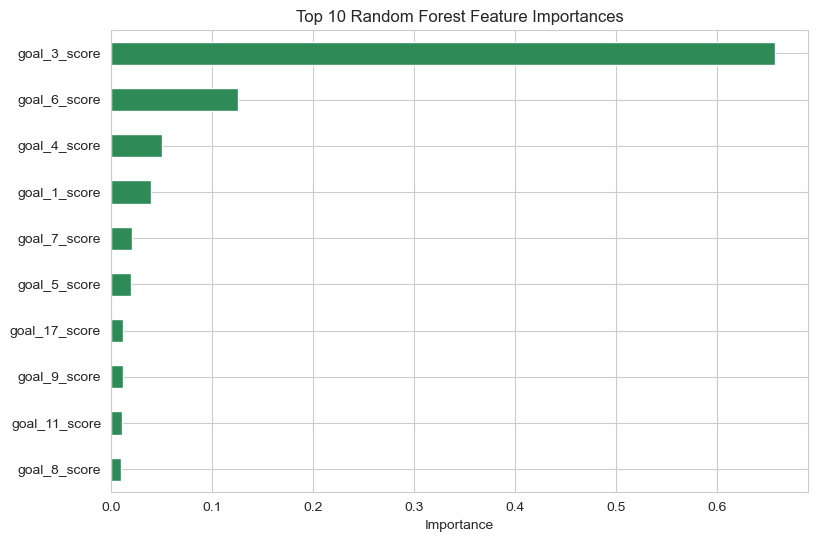

In [231]:
plt.figure(figsize=(9, 6))
importances.head(10).sort_values().plot(kind="barh", color="seagreen")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

<h3>Comparison of the two feature sets</h3>

In [232]:
feature_selection_comparison = pd.DataFrame({
    "SelectKBest (filter, for Ridge)": selected_features_kbest,
    "RF Importance (embedded, for RF)": top8_rf_features,
})
feature_selection_comparison

,"SelectKBest (filter, for Ridge)","RF Importance (embedded, for RF)"
0,goal_3_score,goal_3_score
1,goal_4_score,goal_6_score
2,goal_6_score,goal_4_score
3,goal_7_score,goal_1_score
4,goal_8_score,goal_7_score
5,goal_9_score,goal_5_score
6,goal_11_score,goal_17_score
7,goal_16_score,goal_9_score


In [233]:
common = set(selected_features_kbest) & set(top8_rf_features)
print("Features selected by BOTH methods:", common)
print("Number in common:", len(common))

Features selected by BOTH methods: {'goal_3_score', 'goal_6_score', 'goal_9_score', 'goal_7_score', 'goal_4_score'}
Number in common: 5


**Justification:** `SelectKBest` (F-regression) is used for the linear model because it measures a purely **linear** dependency between each feature and the target - a natural match for Ridge, which is itself a linear model. Random Forest's own **impurity-based feature importance** is used for the tree model because it reflects each feature's actual contribution to reducing prediction error *inside that specific model*, capturing any non-linear/interaction effects a purely linear filter score would miss. Both methods agree that `goal_3_score` (Good Health) dominates, and largely overlap on `goal_4`, `goal_6`, `goal_7` and `goal_9` - consistent with the correlation heatmap from the EDA - which gives confidence that the selection is not an artefact of one particular method.

<h1>TASK 6: FINAL MODELS AND COMPARATIVE ANALYSIS</h1>

<h3>Final Ridge Regression (best alpha + SelectKBest features)</h3>

In [234]:
X_train_ridge = X_train_scaled[:, selector.get_support()]
X_test_ridge = X_test_scaled[:, selector.get_support()]

best_ridge = ridge_search.best_estimator_
best_ridge.fit(X_train_ridge, y_train)
ridge_final_preds = best_ridge.predict(X_test_ridge)

ridge_final_rmse = np.sqrt(mean_squared_error(y_test, ridge_final_preds))
ridge_final_mae = mean_absolute_error(y_test, ridge_final_preds)
ridge_final_r2 = r2_score(y_test, ridge_final_preds)

print("Final Ridge Regression (Selected Features) Performance")
print(f"RMSE: {ridge_final_rmse:.4f}")
print(f"MAE : {ridge_final_mae:.4f}")
print(f"R^2 : {ridge_final_r2:.4f}")

Final Ridge Regression (Selected Features) Performance
RMSE: 2.7360
MAE : 2.1531
R^2 : 0.9391


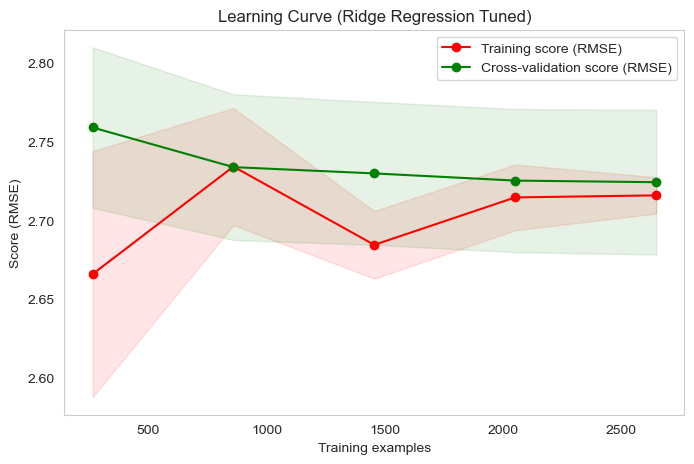

In [235]:
plot_learning_curve(best_ridge, 'Learning Curve (Ridge Regression Tuned)', X_train_ridge, y_train)


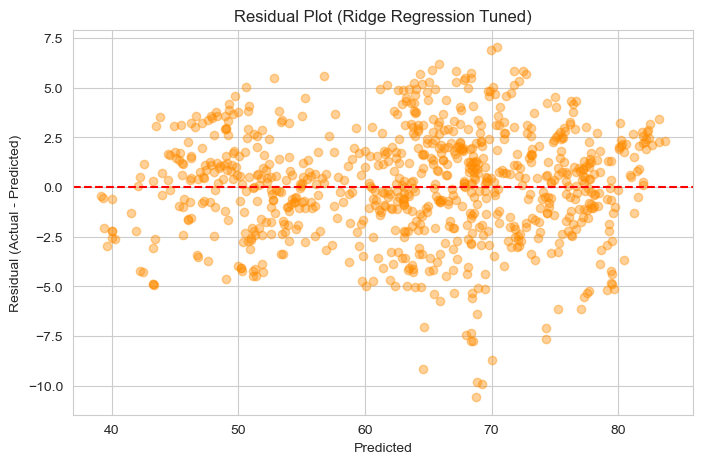

In [236]:
plot_residuals(y_test, ridge_final_preds, 'Residual Plot (Ridge Regression Tuned)')


**Observation (Ridge Tuned Residuals):** The residuals are fairly scattered around zero but show a slight fanning out at the extremes, which implies the linear model struggles slightly with non-linear edge cases, but remains unbiased overall.


<h3>Final Random Forest (best hyperparameters + RF-importance features)</h3>

In [237]:
X_train_rf_sel = X_train[top8_rf_features]
X_test_rf_sel = X_test[top8_rf_features]

best_rf = rf_search.best_estimator_
best_rf.fit(X_train_rf_sel, y_train)
rf_final_preds = best_rf.predict(X_test_rf_sel)

rf_final_rmse = np.sqrt(mean_squared_error(y_test, rf_final_preds))
rf_final_mae = mean_absolute_error(y_test, rf_final_preds)
rf_final_r2 = r2_score(y_test, rf_final_preds)

print("Final Random Forest (Selected Features) Performance")
print(f"RMSE: {rf_final_rmse:.4f}")
print(f"MAE : {rf_final_mae:.4f}")
print(f"R^2 : {rf_final_r2:.4f}")

Final Random Forest (Selected Features) Performance
RMSE: 0.7249
MAE : 0.5343
R^2 : 0.9957


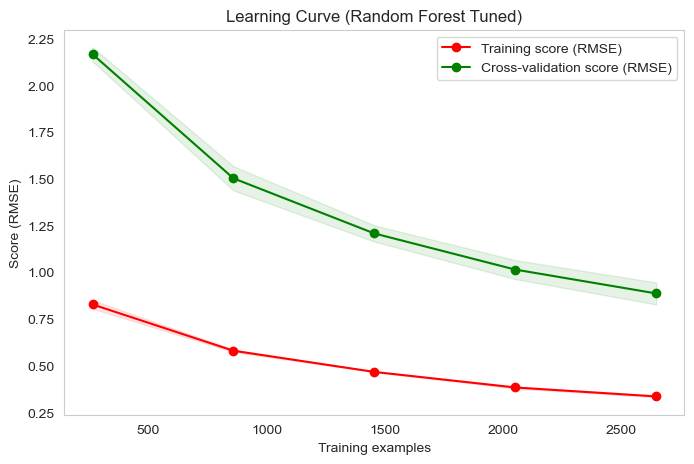

In [238]:
plot_learning_curve(best_rf, 'Learning Curve (Random Forest Tuned)', X_train_rf_sel, y_train)


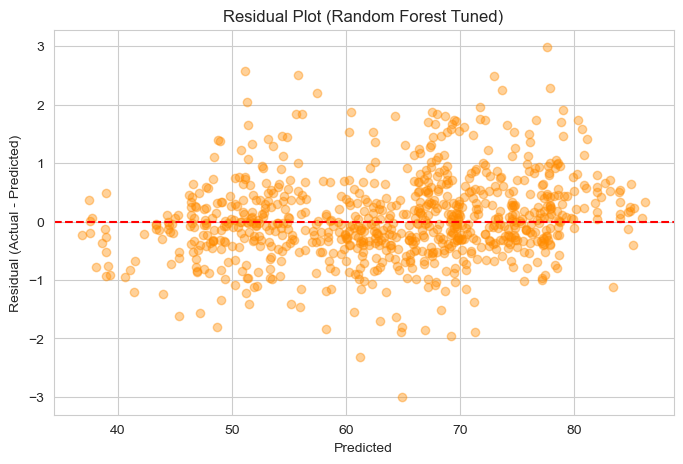

In [239]:
plot_residuals(y_test, rf_final_preds, 'Residual Plot (Random Forest Tuned)')


**Observation (Random Forest Tuned Residuals):** The errors are very small and evenly distributed around zero across the entire prediction range. This confirms that the tuned Random Forest has unbiased, random errors and captures the complex relationships very well.


<h3>Final comparison table</h3>

In [240]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Calculate CV scores for baselines
mlp_cv = -cross_val_score(mlp_model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
lr_cv = -cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
rf_cv = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()

models_summary = []

# Neural Network
models_summary.append({
    'Model': 'Neural Network (MLP)',
    'Variant': 'Baseline (all features)',
    'CV Score (RMSE)': mlp_cv,
    'Test RMSE': mlp_test_rmse,
    'Test MAE': mlp_test_mae,
    'Test R-squared': mlp_test_r2
})

# Linear Regression (baseline)
models_summary.append({
    'Model': 'Linear Regression',
    'Variant': 'Baseline',
    'CV Score (RMSE)': lr_cv,
    'Test RMSE': lr_rmse,
    'Test MAE': lr_mae,
    'Test R-squared': lr_r2
})

# Random Forest (baseline)
models_summary.append({
    'Model': 'Random Forest',
    'Variant': 'Baseline',
    'CV Score (RMSE)': rf_cv,
    'Test RMSE': rf_rmse,
    'Test MAE': rf_mae,
    'Test R-squared': rf_r2
})

# Ridge Regression (tuned + selected)
models_summary.append({
    'Model': 'Ridge Regression',
    'Variant': f'Tuned + Selected ({len(selected_features_kbest)})',
    'CV Score (RMSE)': -ridge_search.best_score_,
    'Test RMSE': ridge_final_rmse,
    'Test MAE': ridge_final_mae,
    'Test R-squared': ridge_final_r2
})

# Random Forest (tuned + selected)
models_summary.append({
    'Model': 'Random Forest',
    'Variant': f'Tuned + Selected ({len(top8_rf_features)})',
    'CV Score (RMSE)': -rf_search.best_score_,
    'Test RMSE': rf_final_rmse,
    'Test MAE': rf_final_mae,
    'Test R-squared': rf_final_r2
})

final_comparison = pd.DataFrame(models_summary)
num_cols = ['CV Score (RMSE)', 'Test RMSE', 'Test MAE', 'Test R-squared']
final_comparison[num_cols] = final_comparison[num_cols].astype(float).round(4)

print("FINAL MODEL COMPARISON TABLE")
final_comparison


FINAL MODEL COMPARISON TABLE


,Model,Variant,CV Score (RMSE),Test RMSE,Test MAE,Test R-squared
0,Neural Network (MLP),Baseline (all features),0.7586,0.6885,0.5295,0.9961
1,Linear Regression,Baseline,1.1083,1.0585,0.8385,0.9909
2,Random Forest,Baseline,0.6806,0.5340,0.3866,0.9977
3,Ridge Regression,Tuned + Selected (8),1.1083,2.7360,2.1531,0.9391
4,Random Forest,Tuned + Selected (8),0.5739,0.7249,0.5343,0.9957


### Observation on Final Comparison
Baseline vs Tuned: The Baseline Random Forest achieved the lowest Test RMSE (0.5340) and highest R² (0.9977), making it the strongest model on the unseen test set. The Tuned Random Forest had the most stable cross-validation (lowest CV RMSE of 0.5739) but failed to generalize quite as well, likely because restricting it to only 8 features discarded valuable predictive information.
Overfitting in Ridge The Ridge Regression (Tuned + Selected) model showed a drastic jump from a CV RMSE of 1.1083 to a Test RMSE of 2.7360. This indicates severe overfitting to the training folds or an over-reliance on the aggressively reduced feature set that didn't translate well to unseen test data.
Consistency: Both the Neural Network (MLP) and the Baseline Linear Regression showed strong consistency between their CV scores and their Test performance, proving they are robust models for this dataset.


<h3>Visual Comparison of RMSE Scores</h3>


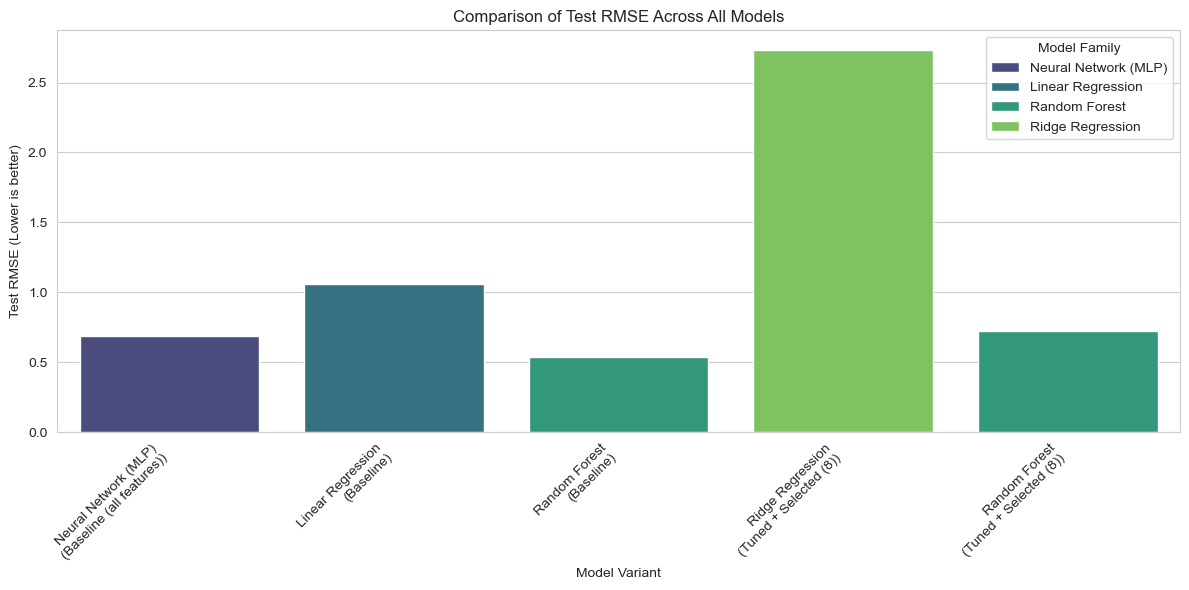

In [241]:
fig, ax = plt.subplots(figsize=(12, 6))
final_comparison['Label'] = final_comparison['Model'] + '\n(' + final_comparison['Variant'] + ')'
sns.barplot(data=final_comparison, x='Label', y='Test RMSE', hue='Model', dodge=False, palette='viridis')
plt.title('Comparison of Test RMSE Across All Models')
plt.ylabel('Test RMSE (Lower is better)')
plt.xlabel('Model Variant')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model Family')
plt.tight_layout()
plt.show()

<h3>Final model: Predicted vs Actual (both models)</h3>

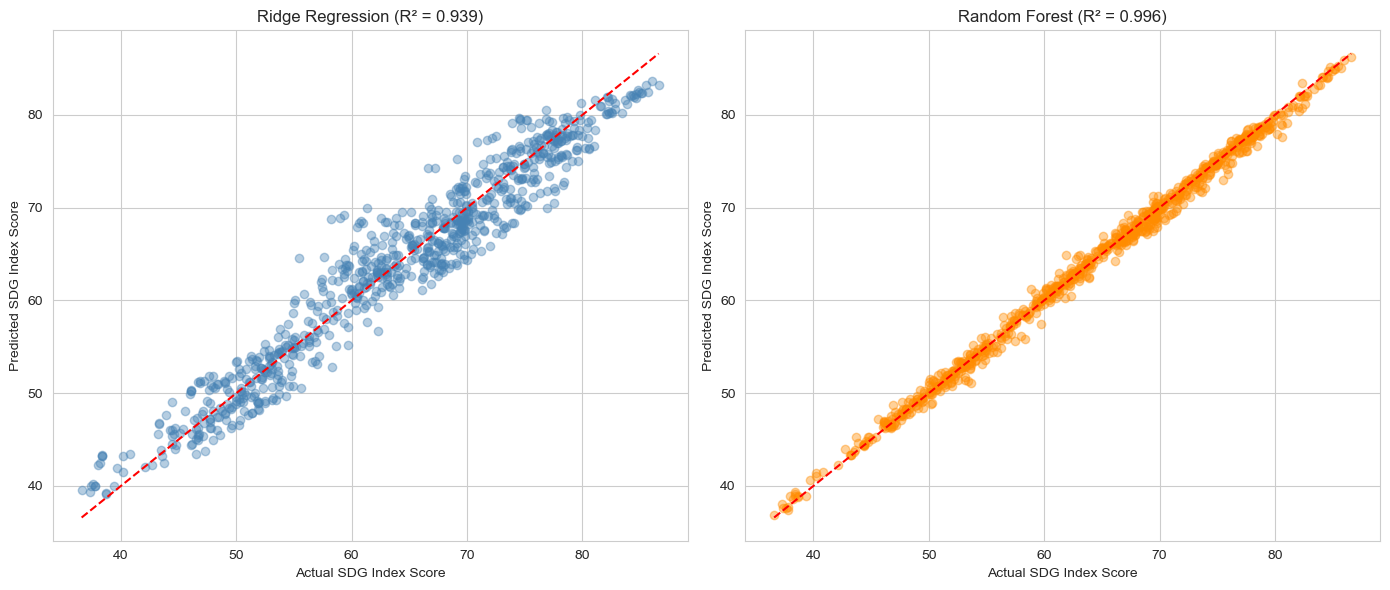

Exception ignored in: <function ResourceTracker.__del__ at 0x104c8dd00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105319d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104d69d00>
Traceback (most recent call last

In [242]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, ridge_final_preds, alpha=0.4, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title(f"Ridge Regression (R² = {ridge_final_r2:.3f})")
axes[0].set_xlabel("Actual SDG Index Score")
axes[0].set_ylabel("Predicted SDG Index Score")

axes[1].scatter(y_test, rf_final_preds, alpha=0.4, color="darkorange")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title(f"Random Forest (R² = {rf_final_r2:.3f})")
axes[1].set_xlabel("Actual SDG Index Score")
axes[1].set_ylabel("Predicted SDG Index Score")
plt.show()